# VoxIntel — 01: SLURP Dataset Audit

Goal of this notebook: understand the SLURP dataset before we train anything.

We answer:
1. How many samples (total / train / validation / test)?
2. How many unique intents, and how many intent classes?
3. Is the dataset balanced?
4. What does the audio duration distribution look like?
5. What do random samples actually look like (transcript, intent, audio)?
6. Is there missing or corrupted data?
7. Summary of findings.

**Assumed folder layout** (adjust `SLURP_ROOT` below if yours differs):

```
data/raw/slurp/
├── dataset/
│   └── slurp/
│       ├── train.jsonl
│       ├── train_synthetic.jsonl   (optional)
│       ├── devel.jsonl
│       └── test.jsonl
└── audio/
    ├── slurp_real/
    └── slurp_synth/
```


In [19]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
from IPython.display import Audio, display

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [20]:
SLURP_ROOT = Path("C:\\Users\\ACER\\OneDrive\\Desktop\\VoxIntel\\data\\raw\\slurp")# data/raw/slurp
ANNOT_DIR = SLURP_ROOT / "dataset" / "slurp"  # jsonl files live here
AUDIO_REAL_DIR = SLURP_ROOT / "audio" / "slurp_real"
AUDIO_SYNTH_DIR = SLURP_ROOT / "audio" / "slurp_synth"

SPLIT_FILES = {
    "train": ANNOT_DIR / "train.jsonl",
    "train_synthetic": ANNOT_DIR / "train_synthetic.jsonl",  # optional, may not exist
    "devel": ANNOT_DIR / "devel.jsonl",
    "test": ANNOT_DIR / "test.jsonl",
}

for name, path in SPLIT_FILES.items():
    status = "found" if path.exists() else "MISSING"
    print(f"{name:16s} -> {path}  [{status}]")


train            -> C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\dataset\slurp\train.jsonl  [found]
train_synthetic  -> C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\dataset\slurp\train_synthetic.jsonl  [found]
devel            -> C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\dataset\slurp\devel.jsonl  [found]
test             -> C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\dataset\slurp\test.jsonl  [found]


## Step 0 — Load and flatten the dataset

Each line in a SLURP `.jsonl` file is one *sentence*, but a sentence can have
**multiple recordings** (different speakers reading the same sentence). We
flatten this so each row = one audio file, with its transcript and intent
attached.

Intent = `scenario_action` (SLURP's own `intent` field is already this
combination, but we recompute it defensively in case a row is missing it).


In [21]:
def load_jsonl(path):
    """Load a SLURP-style jsonl file into a list of dicts. Returns [] if missing."""
    if not path.exists():
        return []
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def flatten_split(records, split_name, audio_dir):
    """One row per (sentence, recording) pair."""
    rows = []
    for rec in records:
        transcript = rec.get("sentence")
        scenario = rec.get("scenario")
        action = rec.get("action")
        intent = rec.get("intent") or (
            f"{scenario}_{action}" if scenario and action else None
        )
        recordings = rec.get("recordings", [])
        if not recordings:
            # Some malformed rows may have no recordings at all
            rows.append({
                "split": split_name,
                "audio_path": None,
                "transcript": transcript,
                "scenario": scenario,
                "action": action,
                "intent": intent,
            })
            continue
        for r in recordings:
            fname = r.get("file")
            audio_path = str(Path(audio_dir) / fname) if fname else None
            rows.append({
                "split": split_name,
                "audio_path": audio_path,
                "transcript": transcript,
                "scenario": scenario,
                "action": action,
                "intent": intent,
            })
    return rows


all_rows = []
all_rows += flatten_split(load_jsonl(SPLIT_FILES["train"]), "train", AUDIO_REAL_DIR)
all_rows += flatten_split(load_jsonl(SPLIT_FILES["train_synthetic"]), "train_synthetic", AUDIO_SYNTH_DIR)
all_rows += flatten_split(load_jsonl(SPLIT_FILES["devel"]), "validation", AUDIO_REAL_DIR)
all_rows += flatten_split(load_jsonl(SPLIT_FILES["test"]), "test", AUDIO_REAL_DIR)

df = pd.DataFrame(all_rows)
print(f"Loaded {len(df):,} rows total")
df.head(15)

Loaded 141,649 rows total


,split,audio_path,transcript,scenario,action,intent
0,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
1,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
2,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
3,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
4,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
5,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
6,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
7,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
8,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
9,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,i need an event three days from now scheduled ...,calendar,set,calendar_set


## 1. How many samples are there?

In [22]:
counts = df["split"].value_counts()
print("Total samples :", len(df))
print()
print(counts)
df.loc[df["split"] == "train_synthetic", "split"] = "train"
df

Total samples : 141649

split
train_synthetic    69253
train              50628
test               13078
validation          8690
Name: count, dtype: int64


,split,audio_path,transcript,scenario,action,intent
0,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
1,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
2,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
3,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
4,train,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,event,calendar,set,calendar_set
...,...,...,...,...,...,...
141644,test,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,submit a negative review about a company,social,post,social_post
141645,test,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,i need you to get me up at six am,alarm,set,alarm_set
141646,test,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,i need you to get me up at six am,alarm,set,alarm_set
141647,test,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,get todays climate forecast here,weather,query,weather_query


## 2. How many unique intents?

(showing a sample of them — full list can be long)

In [23]:
unique_intents = sorted(df["intent"].dropna().unique())
print(f"Unique intents ({len(unique_intents)}):")
for intent in unique_intents:
    print(f"  {intent}")

Unique intents (101):
  addcontact
  alarm_query
  alarm_remove
  alarm_set
  audio_volume_down
  audio_volume_mute
  audio_volume_other
  audio_volume_up
  calendar_query
  calendar_remove
  calendar_set
  cleaning
  coffee
  convert
  cooking_query
  cooking_recipe
  createoradd
  currency
  datetime_convert
  datetime_query
  definition
  email_addcontact
  email_query
  email_querycontact
  email_sendemail
  events
  factoid
  game
  general_affirm
  general_commandstop
  general_confirm
  general_dontcare
  general_explain
  general_greet
  general_joke
  general_negate
  general_praise
  general_quirky
  general_repeat
  greet
  hue_lightdim
  hue_lightoff
  hue_lightup
  iot_cleaning
  iot_coffee
  iot_hue_lightchange
  iot_hue_lightdim
  iot_hue_lightoff
  iot_hue_lighton
  iot_hue_lightup
  iot_wemo_off
  iot_wemo_on
  joke
  likeness
  lists_createoradd
  lists_query
  lists_remove
  locations
  music
  music_dislikeness
  music_likeness
  music_query
  music_settings
  news_

## 3. How many intent classes?

In [24]:
n_intent_classes = df["intent"].nunique(dropna=True)
n_scenarios = df["scenario"].nunique(dropna=True)
n_actions = df["action"].nunique(dropna=True)

print(f"Intent classes : {n_intent_classes}")
print(f"Scenarios      : {n_scenarios}")
print(f"Actions        : {n_actions}")

Intent classes : 101
Scenarios      : 18
Actions        : 54


## 4. Is the dataset balanced?

Bar chart of sample counts per intent, sorted descending. A long tail here
means most intents are rare relative to a few dominant ones — worth knowing
before you pick metrics (accuracy vs. macro-F1) or think about class weighting.


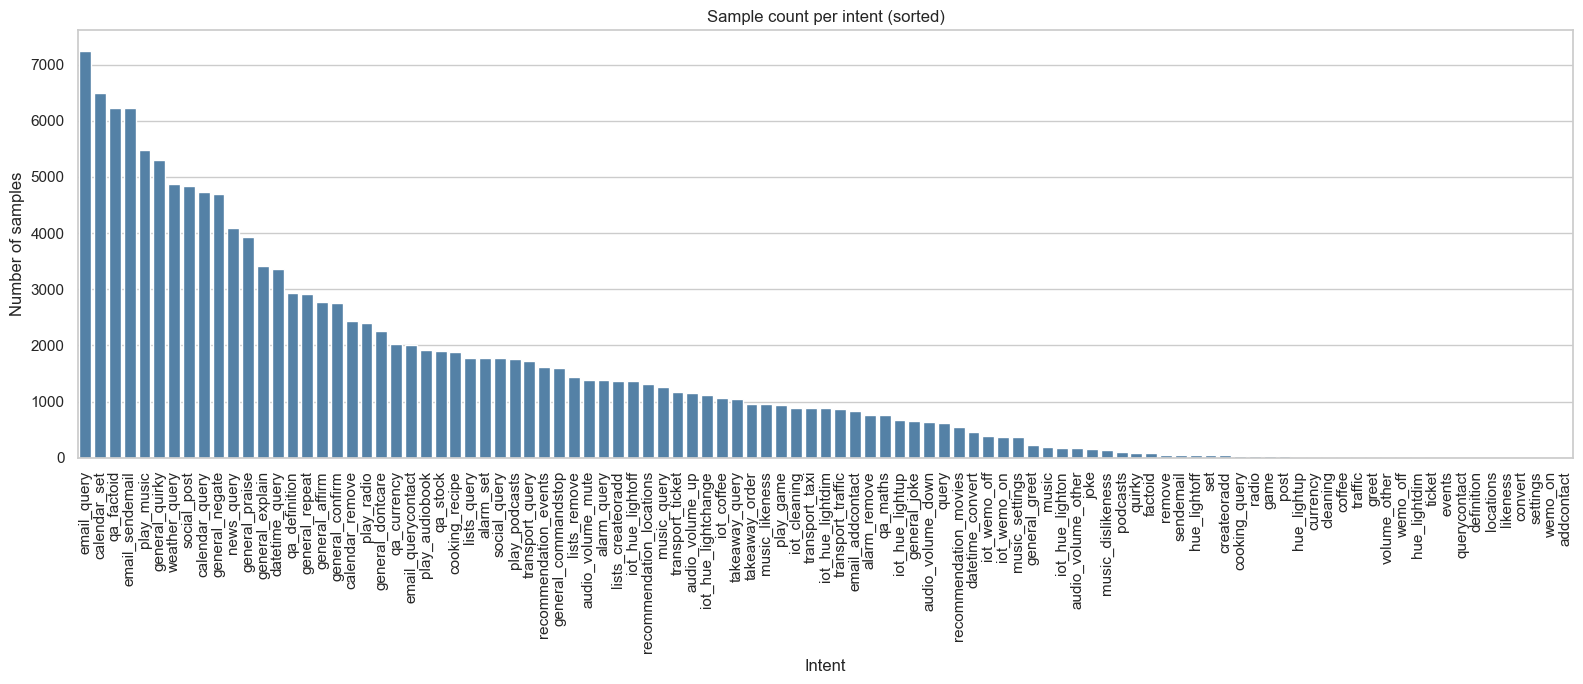

Top 5 most common intents:
intent
email_query        7245
calendar_set       6486
qa_factoid         6227
email_sendemail    6225
play_music         5472
Name: count, dtype: int64

Bottom 5 least common intents:
intent
likeness      5
convert       5
settings      5
wemo_on       4
addcontact    3
Name: count, dtype: int64

Imbalance ratio (max/min class count): 2415.0x


In [25]:
intent_counts = df["intent"].value_counts()

plt.figure(figsize=(16, 7))
sns.barplot(x=intent_counts.index, y=intent_counts.values, color="steelblue")
plt.xticks(rotation=90)
plt.xlabel("Intent")
plt.ylabel("Number of samples")
plt.title("Sample count per intent (sorted)")
plt.tight_layout()
plt.show()

print("Top 5 most common intents:")
print(intent_counts.head())
print()
print("Bottom 5 least common intents:")
print(intent_counts.tail())

imbalance_ratio = intent_counts.max() / intent_counts.min()
print(f"\nImbalance ratio (max/min class count): {imbalance_ratio:.1f}x")


## 5. Audio duration distribution

This reads each audio file's header to get duration (fast — doesn't decode
the whole file). On the full dataset this can still take a few minutes, so
we sample a subset by default; set `SAMPLE_SIZE = None` to run on everything.


In [26]:
def get_duration(path):
    try:
        info = sf.info(path)
        return info.frames / info.samplerate
    except Exception:
        return np.nan


SAMPLE_SIZE = None  # set to None to compute on the full dataset

audio_df = df.dropna(subset=["audio_path"]).copy()
if SAMPLE_SIZE is not None and len(audio_df) > SAMPLE_SIZE:
    duration_sample = audio_df.sample(SAMPLE_SIZE, random_state=RANDOM_SEED).copy()
else:
    duration_sample = audio_df.copy()

duration_sample["duration_sec"] = duration_sample["audio_path"].apply(get_duration)
durations = duration_sample["duration_sec"].dropna()

print(f"Computed durations for {len(durations):,} files")
print(f"Minimum : {durations.min():.2f} sec")
print(f"Maximum : {durations.max():.2f} sec")
print(f"Average : {durations.mean():.2f} sec")
print(f"Median  : {durations.median():.2f} sec")


Computed durations for 141,649 files
Minimum : 0.50 sec
Maximum : 23.36 sec
Average : 2.59 sec
Median  : 2.37 sec


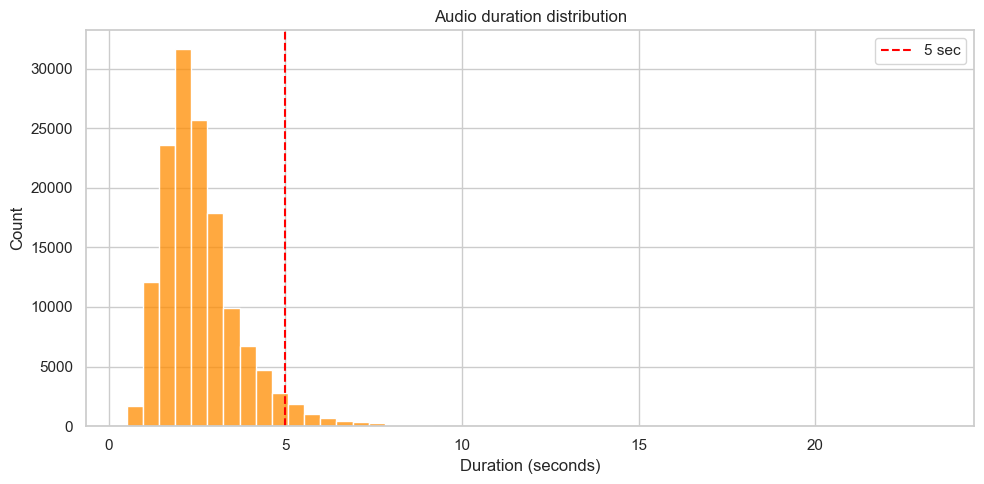

Clips under 5 seconds: 96.3%
Clips above 99th percentile (6.5s): 1397


In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(durations, bins=50, color="darkorange")
plt.axvline(5, color="red", linestyle="--", label="5 sec")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Audio duration distribution")
plt.legend()
plt.tight_layout()
plt.show()

under_5s_pct = (durations < 5).mean() * 100
print(f"Clips under 5 seconds: {under_5s_pct:.1f}%")

outlier_threshold = durations.quantile(0.99)
n_outliers = (durations > outlier_threshold).sum()
print(f"Clips above 99th percentile ({outlier_threshold:.1f}s): {n_outliers}")

## Transcript length

Word count per transcript. Useful for sanity-checking tokenizer max-length
settings later for the intent model, and for spotting outliers (empty or
unusually long transcripts).


Minimum : 1 words
Maximum : 61 words
Average : 6.65 words
Median  : 6.0 words


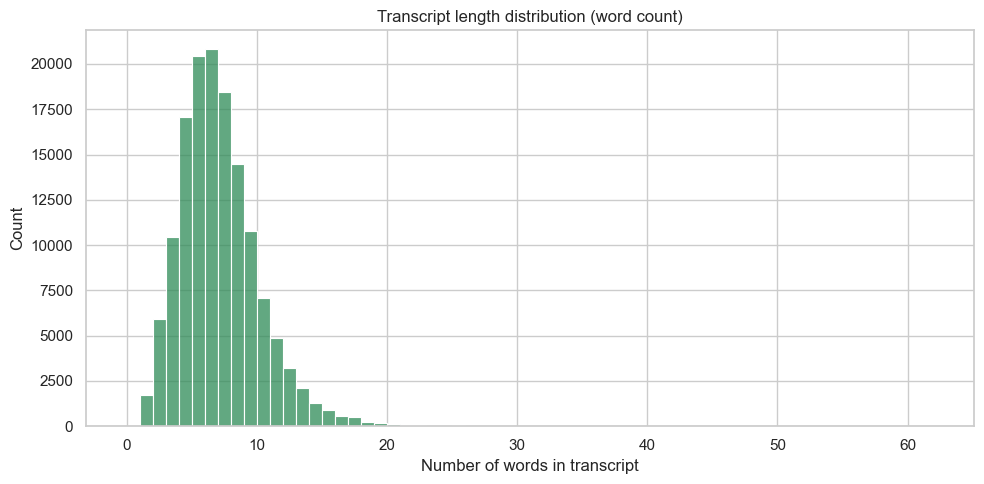

Transcripts with 0 words: 0


In [28]:
df["transcript_word_count"] = (
    df["transcript"].fillna("").str.strip().str.split().apply(len)
)

word_counts = df["transcript_word_count"]
print(f"Minimum : {word_counts.min()} words")
print(f"Maximum : {word_counts.max()} words")
print(f"Average : {word_counts.mean():.2f} words")
print(f"Median  : {word_counts.median():.1f} words")

plt.figure(figsize=(10, 5))
sns.histplot(word_counts, bins=range(0, word_counts.max() + 2), color="seagreen")
plt.xlabel("Number of words in transcript")
plt.ylabel("Count")
plt.title("Transcript length distribution (word count)")
plt.tight_layout()
plt.show()

empty_transcripts = (word_counts == 0).sum()
print(f"Transcripts with 0 words: {empty_transcripts}")


## 6. Inspect random samples

Prints transcript / intent / duration for a handful of random examples.
The first 3 also get an inline audio player so you can actually listen —
run this cell in Jupyter (not in a plain script) to hear them.


In [29]:
N_SAMPLES = 20
sample_rows = audio_df.sample(N_SAMPLES, random_state=RANDOM_SEED)

for i, (_, row) in enumerate(sample_rows.iterrows()):
    dur = get_duration(row["audio_path"])
    print(f"[{i}] split={row['split']}  intent={row['intent']}  duration={dur:.2f}s")
    print(f"     transcript : {row['transcript']}")
    print(f"     audio_path : {row['audio_path']}")
    print()

    if i < 3:
        try:
            display(Audio(row["audio_path"]))
        except Exception as e:
            print(f"     (could not load audio for playback: {e})")


[0] split=train  intent=qa_factoid  duration=1.92s
     transcript : is the celebrity single or married
     audio_path : C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\audio\slurp_synth\audio-1590216693738AaBOl-synth.flac



[1] split=validation  intent=weather_query  duration=4.48s
     transcript : will it be too cold for a dress on sunday
     audio_path : C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\audio\slurp_real\audio-1501608978.flac



[2] split=train  intent=email_sendemail  duration=11.20s
     transcript : send to kmart@shopyourway dot com i am waiting for a response from my earlier email reference number seven hundred and eighty three thousand five hundred and forty three any help would be appreciated
     audio_path : C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\audio\slurp_synth\audio-1590311638740cBolt-synth.flac



[3] split=train  intent=email_query  duration=1.16s
     transcript : check my inbox
     audio_path : C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\audio\slurp_synth\audio-1590220081151otBca-synth.flac

[4] split=train  intent=qa_definition  duration=2.30s
     transcript : describe the heart stone card game
     audio_path : C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\audio\slurp_synth\audio-1590216204833oboaB-synth.flac

[5] split=train  intent=lists_query  duration=2.23s
     transcript : what are all the lists i have
     audio_path : C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\audio\slurp_real\audio-1501690531.flac

[6] split=train  intent=qa_definition  duration=2.93s
     transcript : latest iphone
     audio_path : C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp\audio\slurp_real\audio-1501415278.flac

[7] split=train  intent=general_negate  duration=1.74s
     transcript : it must be a mistake.
     audio_path : C:\Users\ACER\OneDrive\Desk

## 7. Check for missing data

Checks for:
- missing transcripts
- missing audio paths / files that don't exist on disk
- empty intent labels
- corrupted audio files (can't be opened)


In [30]:
missing_transcript = df["transcript"].isna() | (df["transcript"].str.strip() == "")
missing_intent = df["intent"].isna() | (df["intent"].astype(str).str.strip() == "")
missing_audio_path = df["audio_path"].isna()

print(f"Missing transcripts : {missing_transcript.sum()}")
print(f"Missing intent labels: {missing_intent.sum()}")
print(f"Missing audio_path   : {missing_audio_path.sum()}")

# Check files referenced but not actually present on disk
existing_paths = df.dropna(subset=["audio_path"])["audio_path"]
missing_files = [p for p in existing_paths if not Path(p).exists()]
print(f"Referenced audio files not found on disk: {len(missing_files)}")
if missing_files:
    print("  e.g.:", missing_files[:5])


Missing transcripts : 0
Missing intent labels: 0
Missing audio_path   : 0
Referenced audio files not found on disk: 0


In [31]:
# Corruption check — try to open a sample of files (checking ALL files can be slow)
CORRUPTION_CHECK_SAMPLE = 2000
check_paths = audio_df["audio_path"].sample(
    min(CORRUPTION_CHECK_SAMPLE, len(audio_df)), random_state=RANDOM_SEED
)

corrupted = []
for p in check_paths:
    try:
        sf.info(p)
    except Exception:
        corrupted.append(p)

print(f"Checked {len(check_paths)} files, found {len(corrupted)} corrupted/unreadable")
if corrupted:
    print("  e.g.:", corrupted[:5])


Checked 2000 files, found 0 corrupted/unreadable


### Duplicate check

Two kinds of duplication matter here:
- **Duplicate audio files** — the same `audio_path` appearing more than once
  (a bookkeeping bug, not the expected "same sentence, different speaker"
  case, which is normal in SLURP).
- **Duplicate transcripts** — the same sentence text appearing many times
  (expected to some degree in SLURP, since multiple speakers read the same
  prompts — but worth knowing the scale of it for train/test leakage checks).


In [32]:
dup_audio_paths = df["audio_path"].dropna()
n_dup_audio = dup_audio_paths.duplicated().sum()
print(f"Duplicate audio_path rows: {n_dup_audio}")

dup_transcripts = df["transcript"].dropna()
n_dup_transcripts = dup_transcripts.duplicated().sum()
print(f"Duplicate transcript rows (same sentence text, any split): {n_dup_transcripts}")
print(f"Unique transcript texts: {dup_transcripts.nunique()} / {len(dup_transcripts)} rows")

# Leakage check: same transcript appearing in both train and test
train_texts = set(df.loc[df["split"] == "train", "transcript"].dropna())
test_texts = set(df.loc[df["split"] == "test", "transcript"].dropna())
overlap = train_texts & test_texts
print(f"Transcripts appearing in BOTH train and test: {len(overlap)}")


Duplicate audio_path rows: 1
Duplicate transcript rows (same sentence text, any split): 118755
Unique transcript texts: 22894 / 141649 rows
Transcripts appearing in BOTH train and test: 2042


## 8. Summary of findings

Auto-generated summary from the cells above — copy the printed values into
the write-up below (or just keep this cell as your documentation).


In [33]:
print("=" * 60)
print("SLURP DATASET AUDIT SUMMARY")
print("=" * 60)
print(f"Total samples          : {len(df):,}")
for split_name, cnt in counts.items():
    print(f"  {split_name:16s}: {cnt:,}")
print()
print(f"Unique intent classes  : {n_intent_classes}")
print(f"Unique scenarios       : {n_scenarios}")
print(f"Unique actions         : {n_actions}")
print(f"Imbalance ratio        : {imbalance_ratio:.1f}x (max class / min class)")
print()
print(f"Audio duration (sampled n={len(durations)}):")
print(f"  min / median / mean / max : "
      f"{durations.min():.2f}s / {durations.median():.2f}s / "
      f"{durations.mean():.2f}s / {durations.max():.2f}s")
print(f"  % under 5 seconds          : {under_5s_pct:.1f}%")
print()
print("Missing / integrity issues:")
print(f"  missing transcripts        : {missing_transcript.sum()}")
print(f"  missing intent labels      : {missing_intent.sum()}")
print(f"  referenced files not found : {len(missing_files)}")
print(f"  corrupted files (sampled)  : {len(corrupted)} / {len(check_paths)}")
print()
print(f"Transcript length (words) : min={word_counts.min()}, "
      f"median={word_counts.median():.1f}, mean={word_counts.mean():.2f}, "
      f"max={word_counts.max()}")
print(f"Empty transcripts          : {empty_transcripts}")
print()
print(f"Duplicate audio_path rows  : {n_dup_audio}")
print(f"Duplicate transcript rows  : {n_dup_transcripts}")
print(f"Train/test transcript overlap: {len(overlap)}")


SLURP DATASET AUDIT SUMMARY
Total samples          : 141,649
  train_synthetic : 69,253
  train           : 50,628
  test            : 13,078
  validation      : 8,690

Unique intent classes  : 101
Unique scenarios       : 18
Unique actions         : 54
Imbalance ratio        : 2415.0x (max class / min class)

Audio duration (sampled n=141649):
  min / median / mean / max : 0.50s / 2.37s / 2.59s / 23.36s
  % under 5 seconds          : 96.3%

Missing / integrity issues:
  missing transcripts        : 0
  missing intent labels      : 0
  referenced files not found : 0
  corrupted files (sampled)  : 0 / 2000

Transcript length (words) : min=1, median=6.0, mean=6.65, max=61
Empty transcripts          : 0

Duplicate audio_path rows  : 1
Duplicate transcript rows  : 118755
Train/test transcript overlap: 2042


## Conclusion

SLURP is clean and ready to model: across all splits every record carries a transcript, an intent label, and a readable audio file, so no data-repair stage is needed before ASR or intent work.

**Key results**
- Total samples: 141,649 — 50,628 real + 69,253 synthetic train (119,881 combined), 8,690 validation (`devel`), 13,078 test
- Label space: 101 intent classes, 18 scenarios, 54 actions
- Class imbalance: 2415.0x between the largest and smallest intent
- Audio: median 2.37s, mean 2.59s, max 23.36s — 96.3% of clips under 5s
- Integrity: 0 missing transcripts, 0 missing labels, 0 referenced files absent, 0/2000 sampled files corrupt

**Caveat:** The 2415x imbalance argues for macro-F1 over raw accuracy downstream, and 2,042 transcript texts occur in both `train` and `test` — a lexical-leakage risk to keep in mind when reading intent-model scores (SLURP repeats prompts by design: 22,894 unique texts across 141,649 rows).

**Feeds into:** `02_audio_validation` and the baseline ASR in `03`/`04`; these split sizes and the imbalance frame every downstream WER and intent metric.